# TP2 - Linear Correlation


Estimated time: **1** hour

In this lab, you'll go over hands-on exercises using Python to further consolidate your understanding about linear correlation, in particular the Pearson's Correlation Coefficient, and the visualization by means of scatterplot, hexagonal binning plot, correlation matrix and heatmap. Besides, you will explore serial correlation in time series using autocorrelation.

## Outline


* Get familiar with the dataset
* Assignment questions
  * Part 1 - Pearson Correlation Coefficient (PCC),
  * Part 2 - Visualization: scatterplot, hexagonal binning plot,
  * Part 3 - Understanding the principle behind normalizing covariance
  * Part 4 - Correlation matrix, and heatmap
  * Part 5 - Limitation of PCC
  * Part 6 - Autocorrelation 

----


# Get familiar with the data set

### Import Libraries


Install required packages for this lab. `pip` will automatically skip already installed packages

In [1]:
import importlib

required_pkgs = ["numpy", "pandas", "seaborn", "matplotlib", "statsmodels"]
missing_pkgs = [p for p in required_pkgs if importlib.util.find_spec(p) is None]

if missing_pkgs:
    print("⚠️ Missing packages:", ", ".join(missing_pkgs))
    %pip install numpy pandas seaborn==0.13 matplotlib statsmodels
else:
    print("🎉 All packages already installed.")

🎉 All packages already installed.


Import the required packages


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

Load the dataset


In [3]:
# Load the dataset
df = pd.read_csv('university_ranking.csv',encoding='latin-1')  

### Data Description
#### The dataset contains the Times Higher Education World University Rankings 2016-2024, which include more than 1,900 universities across more than 100 countries and regions. The individual field of the dataset is explained below and more information can be found at https://www.timeshighereducation.com/sites/default/files/the_2024_world_university_rankings_methodology.pdf

| Column Name               | Description                                                                                                                                 |
|---------------------------|---------------------------------------------------------------------------------------------------------------------------------------------|
| **Rank**                   | The ranking of the university based on the Overall Score.                                |
| **Name**                   | The name of the university.                                                                                                                |
| **Country**                | The country where the university is located.                                                                                               |
| **Student Population**      | The number of full-time-equivalent students at the university in a certain year.                                                                                  |
| **Students to Staff Ratio** | The ratio of full-time-equivalent students to the number of academic staff, those involved in teaching or research.                              |
| **International Students**  | The percentage of students originating from outside the country of the university.                                                             |
| **Female to Male Ratio**    | The ratio of female to male students at the university.                                                      |
| **Overall Score**           | A composite score representing the overall performance of the university computed based on various performance indicators.                   |
| **Teaching**                | A score representing the university's teaching, which may include factors like teaching reputation, student staff ratio, doctorate bachelor ratio, doctorate staff ratio           |
| **Research Environment**    | A score representing the univiersity's research environment, which may include factors like reserach reputation, research income, research productivity.                           |
| **Research Quality**        | A score representing the university's research quality, which may include factors like citation impact, research strength, research excellence, and research influence.       |
| **Industry Impact**         | A score representing the university’s industry impact,  which may include factors like industry income, patents                    |
| **International Outlook**   | A score representing the university's global outlook, which may include factors like  international students, international staff, international co-authorship, etc.                   |
| **Year**                    | The year of the data.                                                                                |


### Display the dataset


In [4]:
df

,Rank,Name,Country,Student Population,Students to Staff Ratio,International Students,Female to Male Ratio,Overall Score,Teaching,Research Environment,Research Quality,Industry Impact,International Outlook,Year
0,1.0,California Institute of Technology,United States,2243,6.9,26%,33 : 67,95.2000,95.6,97.6,99.8,97.8,64.0,2016
1,2.0,University of Oxford,United Kingdom,19920,11.6,34%,46:54:00,94.2000,86.5,98.9,98.8,73.1,94.4,2016
2,3.0,Stanford University,United States,15596,7.8,22%,42:58:00,93.9000,92.5,96.2,99.9,63.3,76.3,2016
3,4.0,University of Cambridge,United Kingdom,18810,11.8,34%,46:54:00,92.8000,88.2,96.7,97.0,55.0,91.5,2016
4,5.0,Massachusetts Institute of Technology,United States,11074,9.0,33%,37 : 63,92.0000,89.4,88.6,99.7,95.4,84.0,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12425,1900.0,Penza State University,Russian Federation,17934,17.2,12%,56:44:00,12.1935,14.3,8.7,7.8,16.3,32.8,2024
12426,1901.0,Universidad Peruana de Ciencias Aplicadas (UPC),Peru,56595,21.1,1%,50:50:00,12.1470,13.5,8.7,10.1,15.6,26.5,2024
12427,1902.0,Universidade Federal Rural do Semi-Arido,Brazil,8687,12.4,0%,49:51:00,11.9910,19.1,9.0,5.7,16.6,18.3,2024
12428,1903.0,State University of Bahia,Brazil,25067,11.9,0%,66:34:00,11.5655,19.3,8.6,4.1,16.2,20.0,2024


#### Get info about the dataset 

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12430 entries, 0 to 12429
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rank                     12430 non-null  float64
 1   Name                     12430 non-null  str    
 2   Country                  12430 non-null  str    
 3   Student Population       12430 non-null  int64  
 4   Students to Staff Ratio  12430 non-null  float64
 5   International Students   12430 non-null  str    
 6   Female to Male Ratio     11839 non-null  str    
 7   Overall Score            12430 non-null  float64
 8   Teaching                 12430 non-null  float64
 9   Research Environment     12430 non-null  float64
 10  Research Quality         12430 non-null  float64
 11  Industry Impact          12430 non-null  float64
 12  International Outlook    12430 non-null  float64
 13  Year                     12430 non-null  int64  
dtypes: float64(8), int64(2), str(4)
m

#### Retrieve the data related to University of Luxembourg

In [6]:
uniLU = df[df['Name']=='University of Luxembourg'].set_index('Year')
uniLU

,Rank,Name,Country,Student Population,Students to Staff Ratio,International Students,Female to Male Ratio,Overall Score,Teaching,Research Environment,Research Quality,Industry Impact,International Outlook
Year,,,,,,,,,,,,,
2016,193.0,University of Luxembourg,Luxembourg,5144,15.9,52%,50:50:00,49.4000,25.0,26.7,84.8,38.1,99.8
2017,179.0,University of Luxembourg,Luxembourg,5219,17.2,55%,51:49:00,52.1575,29.7,30.0,85.8,40.6,99.9
2018,179.0,University of Luxembourg,Luxembourg,4969,14.6,57%,50:50:00,53.8050,26.8,32.4,91.9,39.6,99.8
2019,205.0,University of Luxembourg,Luxembourg,4969,16.5,57%,50:50:00,52.8875,29.5,30.6,87.7,42.8,99.7
2020,203.0,University of Luxembourg,Luxembourg,4654,18.7,49%,51:49:00,53.6675,37.9,36.5,75.8,45.2,99.7
2021,224.0,University of Luxembourg,Luxembourg,4858,19.0,51%,52:48:00,51.7700,35.7,35.0,73.2,45.2,99.6
2022,261.0,University of Luxembourg,Luxembourg,4890,19.1,52%,53:47:00,50.0150,33.0,39.2,65.7,47.3,99.5
2023,244.0,University of Luxembourg,Luxembourg,5185,19.3,51%,53:47:00,51.4850,38.2,39.8,64.5,51.2,99.4
2024,243.0,University of Luxembourg,Luxembourg,5599,21.3,49%,53:47:00,56.0480,39.6,39.4,78.1,63.0,93.2


#### Retrieve the data related to Oxford University

In [7]:
oxford = df[df['Name']=='University of Oxford'].set_index('Year')
oxford

,Rank,Name,Country,Student Population,Students to Staff Ratio,International Students,Female to Male Ratio,Overall Score,Teaching,Research Environment,Research Quality,Industry Impact,International Outlook
Year,,,,,,,,,,,,,
2016,2.0,University of Oxford,United Kingdom,19920,11.6,34%,46:54:00,94.2000,86.5,98.9,98.8,73.1,94.4
2017,1.0,University of Oxford,United Kingdom,19720,10.9,35%,46:54:00,95.0200,89.6,99.1,99.2,62.5,94.5
2018,1.0,University of Oxford,United Kingdom,20410,11.2,38%,46:54:00,94.3075,86.7,99.5,99.1,63.7,95.0
2019,1.0,University of Oxford,United Kingdom,20300,11.0,40%,46:54:00,96.0175,91.8,99.5,99.1,67.0,96.3
2020,1.0,University of Oxford,United Kingdom,20665,11.2,41%,46:54:00,95.4175,90.5,99.6,98.4,65.5,96.4
2021,1.0,University of Oxford,United Kingdom,20775,11.1,41%,46:54:00,95.6175,91.3,99.6,98.0,68.7,96.4
2022,1.0,University of Oxford,United Kingdom,20835,10.7,42%,47:53:00,95.6625,91.0,99.6,98.0,74.4,96.3
2023,1.0,University of Oxford,United Kingdom,20965,10.6,42%,48:52:00,96.3875,92.3,99.7,99.0,74.9,96.2
2024,1.0,University of Oxford,United Kingdom,21750,10.9,42%,49:51:00,98.4575,96.6,100.0,99.0,98.7,97.5


#### The "International Students" column contains percentage value which is represented as a string, convert it to decimal value to prepare for the following exercise

In [ ]:
# Check if the 'International Students' column contains a '%' symbol
if df['International Students'].str.contains('%').any():
    # If it contains '%', strip the '%' and convert to numeric
    df['International Students'] = pd.to_numeric(df['International Students'].str.rstrip('%'), errors='coerce') / 100.0

df.head()

,Rank,Name,Country,Student Population,Students to Staff Ratio,International Students,Female to Male Ratio,Overall Score,Teaching,Research Environment,Research Quality,Industry Impact,International Outlook,Year
0,1.0,California Institute of Technology,United States,2243,6.9,0.26,33 : 67,95.2,95.6,97.6,99.8,97.8,64.0,2016
1,2.0,University of Oxford,United Kingdom,19920,11.6,0.34,46:54:00,94.2,86.5,98.9,98.8,73.1,94.4,2016
2,3.0,Stanford University,United States,15596,7.8,0.22,42:58:00,93.9,92.5,96.2,99.9,63.3,76.3,2016
3,4.0,University of Cambridge,United Kingdom,18810,11.8,0.34,46:54:00,92.8,88.2,96.7,97.0,55.0,91.5,2016
4,5.0,Massachusetts Institute of Technology,United States,11074,9.0,0.33,37 : 63,92.0,89.4,88.6,99.7,95.4,84.0,2016


# Assignment questions

## <span style="color:blue">[2.5 Points]</span> Part 1 - Pearson Correlation Coefficient

The **Pearson Correlation Coefficient** is calculated as:

$$
\textcolor{blue}{\Large r = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y}}
$$

where <br>
- $\text{Cov(X,Y)}$ is the covariance between $X$ and $Y$ <br>
- $\sigma_X$ is the standard deviation of $X$ <br>
- $\sigma_Y$ is the standard deviation of $Y$ <br>

More specifically, 
$$ 
\large
\begin{align*}
\text{Cov}(X, Y) = \frac{1}{n} \sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y}) \\ \\
\text{Variance(X)} \quad = \quad \frac{\sum_{i=1}^{n} (X_i - \bar{X})^2}{n}  \\ \\
\text{Standard deviation}  \quad \sigma_X \quad = \quad \sqrt{\text{Variance(X)}} \\ \\
\end{align*}
$$

Hence, 
$$
\Large r = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y } = 
\frac{\sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum_{i=1}^{n} (X_i - \bar{X})^2} \sqrt{\sum_{i=1}^{n} (Y_i - \bar{Y})^2}}
$$



#### **Q1-1**: compute the Pearson Correlation Coefficient (PCC) between Overall Score and Teaching using the formula above. 

**Requirement**: you can use the **.cov()** and **.std()** function for the computation of the covariance and standard deviation respectively. Printout the manually computed PCC value. It is sufficient to keep 2 digits after the decimal point.

In [18]:
print(f"{(df['Overall Score'].cov(df['Teaching']))/(df['Overall Score'].std() * df['Teaching'].std()):.2f}")

0.84


#### **Q1-2**: compute the Pearson Correlation Coefficient (PCC) between Overall Score and Teaching using directly the `.corr()` function. And compare it with the manually calculated value above. Do they match each other?

In [22]:
print(f"{df['Overall Score'].corr(df['Teaching']):.2f}")

0.84


#### **Q1-3**: based on the PCC value, how would you describe the correlation between Overall Score and Teaching: strong, moderate, or weak? Justify your answer. 

----
<div style="color:blue">

The correlation between the Overall score and Teaching is strong. A PCC value of 1.0 indicates a perfect linear relationship between the two variables. 0.86 is considered to be a high PCC value.

</div>

----

#### **Q1-4**: based on the above formula, explain why PCC(X, Y) == PCC(Y,X)?

----
<div style="color:blue">

The PCC value is calcuated by taking the Covariance of the two variables and diving that covariance by the product of their standard deviations. Because the Covariance function is commutative and because multipication is commutative, the order in which you input the variables into the PCC function has no effect on the output.

</div>

----

## <span style="color:blue">[4 Points]</span> Part 2 - Visualization of correlation

Scatterplot is commonly used to conduct visual exploration of possible correlation between variables. With respect to scatterplot, the hexagonal binning plot comes handy for large datasets, as it can differentiate the density of data points in each hexagon by means of color density. 

Each hexgonal bin summarizes the count or the frequency of data points that fall within the area covered by that hexagon. It uses color density to differentiate data density.

#### **Q2-1**: use scatterplot and the hexagonal binning plot to visualize the correlation between Overall Score and Teaching </span>

**Requirement**: generate **scatterplot** and **hexagonal binning plot** to visualize the correlation between Overall Score and Teaching, with Teaching on the x-axis and Overall score on the y-axis. Show the 2 plots **side-by-side** on the same row. 

Hint: you can use scatterplot() function from the Seaborn library and the hexbin() function from the Matplotlib library. Similar functions from other libraries would also be fine.

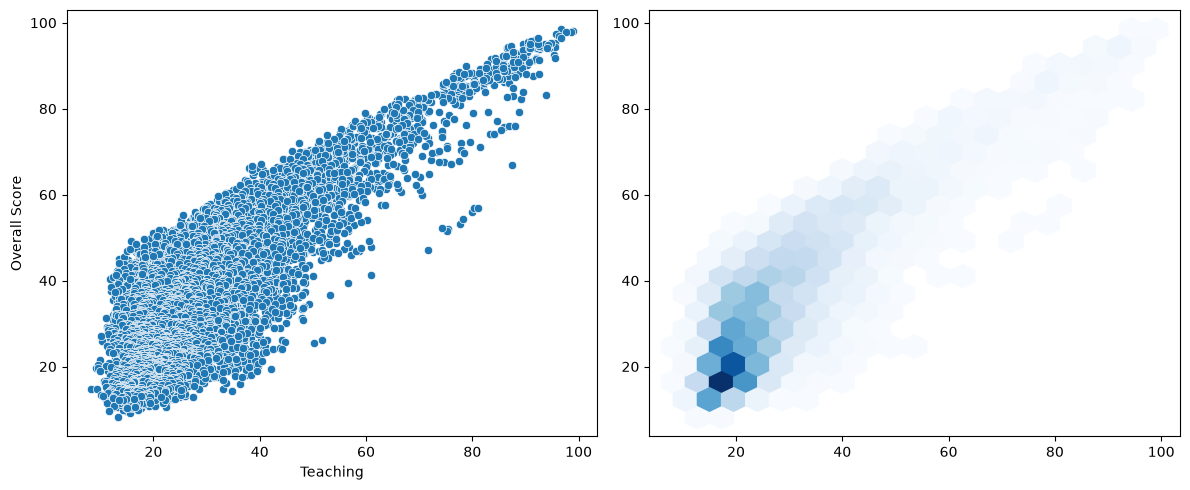

In [14]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df,x="Teaching", y ="Overall Score")

plt.subplot(1, 2, 2)
plt.hexbin(x=df["Teaching"], y=df["Overall Score"], gridsize=20, mincnt=1, cmap="Blues")

plt.tight_layout()
plt.show()

#### **Q2-2**: According to the scatter plot above, is the relationship between Overall Score and Teaching approximately linear? Justify your answer based on the scatter plot. 

----
<div style="color:blue">

Yes. Based on the scatterplot above, the data points appear to be showing an approximately linear relationship. For every unit of teaching there appears to be an associated unit for the overall score. This ratio applies to the majority of the data points indicating an aproximately linear relationship.

</div>

----

#### **Q2-3**: How do the scatter plot and the computed PCC value complement each other when assessing the linear correlation between Teaching and Overall Score?

----
<div style="color:blue">

The PCC value indicates if there is a strong, weak, or nonexistent linear relationship between the two data sets. However, two distinct graphs could appear extremely different and also have the same PCC value. Using a scatterplot allows us to have a better understanding of the relationship between the two data sets.

</div>

----

#### **Q2-4**: According to the hexagonal binning plot, which region contains the highest concentration of observations? What does this tell us about the most common combinations of Teaching and Overall Score?

----
<div style="color:blue">

According to the hexagonal binning plot, the region around 19 teaching and 18 overall score appears to have the highest concentration. This tells us that most of the data points reside in proximity of 19 teaching and 18 overall score.
</div>

----

## <span style="color:blue">[4 Points]</span> Part 3 - Understand the principle behind normalizing the covariance 

$$ 
\large
\begin{align*}
\text{Variance(X)} \quad = \quad \frac{\sum_{i=1}^{n} (X_i - \bar{X})^2}{n}  \\ \\
\text{Standard deviation}  \quad \sigma_X \quad = \quad \sqrt{\text{Variance(X)}} \\ \\
\text{Cov}(X, Y) = \frac{1}{n} \sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y}) \\ \\
\Large r = \frac{\text{cov}(X, Y)}{\sigma_X \sigma_Y}
\end{align*}
$$

We will use **International Outlook** and the **percentage of International Students** for this group of exercises. First of all, we build a new data frame which contains only the International Students and International Outlook columns.

In [ ]:
# Build a new data frame which contains only the International Students and International Outlook columns
new_df_1 = df[['International Students', 'International Outlook']].copy()
new_df_1

Next, instead of representing the percentage of international students as a floating point value between [0.0, 1.0], we represent it as an integer value between [0, 100], by **scaling it up by 100 times**.

In [ ]:
new_df_2 = df[['International Students', 'International Outlook']].copy()
new_df_2['International Students'] = new_df_2['International Students'] * 100
new_df_2

#### **Q3-1**: Compute the covariance between International Outlook and the percentage of International students based on **new_df_1**, and store the result in variable **covariance_1**.

In [ ]:
# insert your code here

#### **Q3-2**: Compute the covariance between International Outlook and the percentage of International students based on **new_df_2**, and store the result in variable **covariance_2**.

In [ ]:
# insert your code here

#### **Q3-3**: according to the results in Q3-1 and Q3-2, answer: 
1) What is the numerical relationship between the covariance value before and after scaling? Explain your answer.
2) Does larger covariance value necessarily indicate stronger correlation? Explain your answer using this example.
3) Explain why the numeric covariance value changes in that way, your explanation should be based on how covariance is calculated. Here is the formula for your reference  $\text{Cov}(X, Y) = \frac{1}{n} \sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})$ 

----
<div style="color:blue">

**Answer**: insert your answer here.

</div>

----

#### **Q3-4**: compute the pearson correlation coefficient between the two variables before and after the scaling

In [ ]:
# Insert your code here

#### **Q3-5**: Does the Pearson correlation coefficient change after we scale up the unit of International Students by 100 times? Support your answer with numeric evidence. Based on this result, explain why PCC is generally more suitable than covariance for measuring the strength of a linear correlation.

----
<div style="color:blue">

**Answer**: insert your answer here.

</div>

----

## <span style="color:blue">[4 Points]</span> Part 4 - Correlation matrix and heatmap 

#### **Q4-1**: generate the correlation matrix between International Outlook, Student Population, Students to Staff Ratio, and International Students. And display it.

Note: it is sufficient to keep 2 digits after the decimal points.

Hint: you can first extract the four columns, and then apply the .corr() function to it. It would be fine if you implement in other ways.

In [ ]:
# insert your code here

#### **Q4-2**: based on the correlation matrix above, identify a pair of variables that has strong linear correlation. Justify your answer with numeric evidence.

----
<div style="color:blue">

**Answer**: insert your answer here.

</div>

----

#### **Q4-3**: Based on the correlation matrix, identify a pair of variables whose PCC value is very close to 0. Explain what does a PCC value equal to, or very close to, 0 indicate?  

----
<div style="color:blue">

**Answer**: insert your answer here.

</div>

----

#### **Q4-4**: Explain why the correlation matrix is sysmmetric along the diagonal.  

----
<div style="color:blue">

**Answer**: insert your answer here.

</div>

----

#### **Q4-5**: generate the heatmap corresponding to the correlation matrix above , similar to the one shown in the lecture slide.

Hint: You can use the .heatmap() function from the seaborn library. It would also be fine if you use similar function from other library.

In [ ]:
# Insert your code here.

## <span style="color:blue">[3.5 Points]</span> Part 5 - Understand limitation of PCC 

Load the 3 datasets used for this exercise. Each dataset contains 300 pairs of data points.

In [ ]:
# Load the 3 datasets
df1 = pd.read_csv("dataset1.csv")
df2 = pd.read_csv("dataset2.csv")
df3 = pd.read_csv("dataset3.csv")

# Display the first 10 entries
df1.head(10)

#### **Q5-1**: compute the PCC value for the 3 datasets and print them out.

In [ ]:
# insert your code here

#### **Q5-2**: based on the above result, answer do the 3 datasets have same PCC value or not? Justify your answer with numeric evidence.

----
<div style="color:blue">

**Answer**: insert your answer here.

</div>

----

#### **Q5-3**: generate the scatterplot for the 3 datasets and display them side-by-side on the same row.

In [ ]:
# insert your code here

#### **Q5-4**: Do the three datasets show similar patterns of relationship between X and Y? Name 2 limitations of using PCC? Justify both your answers based on the above output.

----
<div style="color:blue">

**Answer**: insert your answer here.

</div>

----

## <span style="color:blue">[2 Points]</span> Part 6 - Autocorrelation 

Autocorrelation calculates the linear dependence of a time series with itself at two points in time, e.g. between time *t* and *t+k* (*k* is the “lag”). It is useful to find patterns in data and gives a first estimate of the extent to which a time series is predictable (with a linear model!)

$$
\large 
\rho_k = \frac{\sum_{t=1}^{n-k} (x_t - \bar{x})(x_{t+k} - \bar{x})}{\sum_{t=1}^{n} (x_t - \bar{x})^2}
$$

where 
- $\rho_k$ is the autocorrelation at lag $k$
- $x_t$ is the value of the time series at time $t$
- $x_{t+k}$ is the value of the time series at time $t+k$
- $\bar{x}$ is the mean of the time series
- $n$ is the total number of observations

For this group of exercise, you will perform autocorrelation analysis for Amazon stock price in the past 5 years, with a lag of up to 12 months in the past.

First of all, install the required Python package

In [ ]:
# Install the Python package yfinance, which allows to access historical market data from Yahoo Finance.
%pip install --upgrade --no-cache-dir yfinance 

Next, obtain the Amazon past 5 years stock price, with an interval of 1 month.

In [ ]:
import yfinance as yf

# Retrieve the past 5 years of Amazon stock price data with an interval of 1 month.
ticker = 'AMZN'
amazon_stock_data = yf.download(ticker, period='5y', interval='1mo', progress=False, auto_adjust=True)

# Select the 'Close' price for analysis
amazon_close_price = amazon_stock_data['Close']
#print(amazon_close_price)

# Plot the stock price trend over the past 5 years
plt.figure(figsize=(10, 6))
plt.plot(amazon_close_price, label='Amazon Close Price')
plt.title('Amazon Stock Price (Past 5 Years)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

#### **Q6-1**: Plot the autocorrelation with a lag of up to 12 months using the plot_acf() function from the statsmodels library.

Note: In the plot generated by plot_acf(), the vertical line displays the autocorrelation value. The shaded blue area represents the 95% confidence level. Autocorrelations that fall outside these intervals are considered statistically significant: “there is only a 5% chance that this correlation occurred by random chance”

In [ ]:
# insert your code here

#### **Q6-2**: based on the correlogram plotted above, is the current stock price more strongly correlated with the stock price 1 month ago or 3 months ago? Justify your answer.

----
<div style="color:blue">

**Answer**: insert your answer here.

</div>

----